In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter


In [ ]:
# Step 1: Define dataset directory
dataset_dir = "/content/drive/MyDrive/Brain_tumor/DataSet"


In [ ]:
# Step 2: Load Image Paths and Labels
image_paths = []
labels = []

for label in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, label)
    if os.path.isdir(class_dir) and not label.startswith('.'):  # Skip hidden directories
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                image_paths.append(os.path.join(class_dir, img_file))
                labels.append(label)

In [ ]:
print(f"Total images found: {len(image_paths)}")
print(f"Unique labels: {set(labels)}")

Total images found: 3087
Unique labels: {'Tumor', 'Without_Tumor'}


In [ ]:
# Step 3: Encode Labels
le = LabelEncoder()
labels_numeric = le.fit_transform(labels)
print("Numerical Labels:", labels_numeric)
print("Label Classes:", le.classes_)

# Step 4: Verify Class Distribution
counter = Counter(labels_numeric)
print("Class distribution:", counter)

# Ensure there are at least two classes
if len(counter) < 2:
    raise ValueError("The dataset contains only one class. Please check your labels and dataset.")

Numerical Labels: [0 0 0 ... 1 1 1]
Label Classes: ['Tumor' 'Without_Tumor']
Class distribution: Counter({1: 1586, 0: 1501})


In [ ]:
labels

['Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',


In [ ]:
# Step 1: Load the pre-trained ResNet model (without top layers)
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

# Function to extract features from images
def extract_features(image_paths):
    features = []
    for path in image_paths:
        # Load and preprocess the image
        img = load_img(path, target_size=(224, 224))  # Resize to match ResNet50 input size
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)  # Preprocess for ResNet model
        feature = resnet_model.predict(img_array)
        features.append(feature.flatten())  # Flatten the feature vector
    return np.array(features)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Step 2: Extract features from the images
features = extract_features(image_paths)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
labels

['Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',
 'Tumor',


In [ ]:
# Example original labels (make sure to replace this with your actual labels)

label_encoder = LabelEncoder()
label_encoder.fit(labels)

# Then transform your labels into numeric format
labels_numeric = label_encoder.transform(labels)


In [ ]:
classes=le.classes_
classes

array(['Tumor', 'Without_Tumor'], dtype='<U13')

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Ensure pandas is imported
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tqdm import tqdm
from PIL import Image

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(labels)

LabelEncoder()

In [ ]:
# Step 5: Dimensionality Reduction with t-SNE
def reduce_dimensions(features, n_components=2):
    tsne = TSNE(n_components=n_components, perplexity=30, n_iter=1000, random_state=42)
    features_tsne = tsne.fit_transform(features)
    return features_tsne

features_tsne = reduce_dimensions(features)

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
!pip show Pillow


Name: pillow
Version: 10.4.0
Summary: Python Imaging Library (Fork)
Home-page: https://python-pillow.org
Author: 
Author-email: "Jeffrey A. Clark" <aclark@aclark.net>
License: HPND
Location: /usr/local/lib/python3.10/dist-packages
Requires: 
Required-by: bokeh, dopamine_rl, fastai, imageio, imgaug, matplotlib, scikit-image, torchvision, wordcloud


In [ ]:
!pip install --upgrade Pillow


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


AttributeError: ANTIALIAS

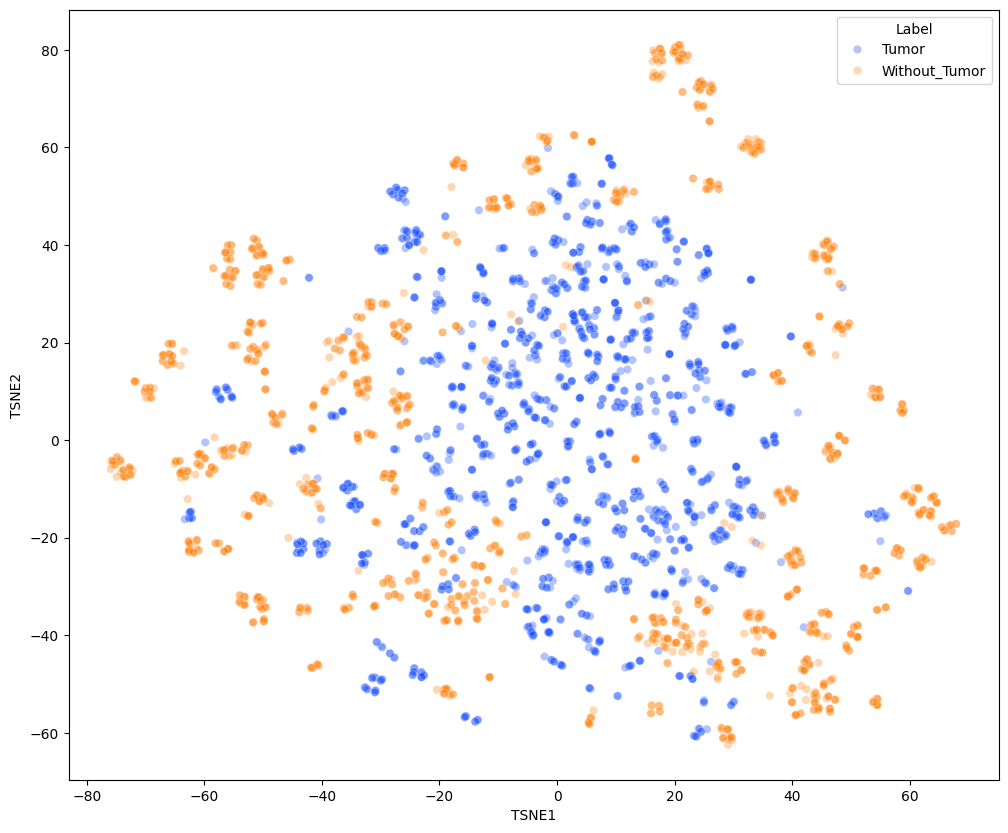

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Make sure to import pandas
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tqdm import tqdm
from PIL import Image

# Step 5: Dimensionality Reduction with t-SNE
def reduce_dimensions(features, n_components=2):
    tsne = TSNE(n_components=n_components, perplexity=30, n_iter=1000, random_state=42)
    features_tsne = tsne.fit_transform(features)
    return features_tsne

features_tsne = reduce_dimensions(features)

# Step 6: Overlay Sample Images on t-SNE Plot
def plot_images_on_tsne(features_reduced, image_paths, labels, label_encoder):
    plt.figure(figsize=(12, 10))
    palette = sns.color_palette("bright", len(np.unique(labels)))

    # Create a DataFrame for plotting
    plot_data = pd.DataFrame({
        'TSNE1': features_reduced[:, 0],
        'TSNE2': features_reduced[:, 1],
        'Label': label_encoder.inverse_transform(labels)  # Convert back to original labels
    })

    sns.scatterplot(
        x='TSNE1',
        y='TSNE2',
        hue='Label',
        palette=palette,
        data=plot_data,
        alpha=0.3
    )

    # Overlay images
    for idx in range(len(image_paths)):
        img = Image.open(image_paths[idx])
        img.thumbnail((30, 30), Image.Resampling.ANTIALIAS)  # Resize for overlay
        img_np = np.array(img)

        if img_np.ndim == 2:
            img_np = np.stack((img_np,) * 3, axis=-1)  # Convert grayscale to RGB

        # Coordinates for the image
        x, y = features_reduced[idx, 0], features_reduced[idx, 1]
        plt.imshow(img_np, extent=(x-0.05, x+0.05, y-0.05, y+0.05), aspect='auto')

    plt.title('t-SNE Visualization of ResNet50 Extracted Features with Images')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Class')
    plt.show()

# Call the plotting function with the label encoder
plot_images_on_tsne(features_tsne, image_paths, labels_numeric, label_encoder)


In [ ]:
# Step 4: Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(features, labels_numeric, test_size=0.2, random_state=42)


In [ ]:
X_train.shape

(2469, 2048)

In [ ]:
y_train.shape

(2469,)

In [ ]:
# Initialize the SVM classifier with a linear kernel
svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)

# Train the model
svm_classifier.fit(X_train, y_train)


SVC(kernel='linear', random_state=42)

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
print(accuracy)


# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




0.9854368932038835
Confusion Matrix:
[[306   9]
 [  0 303]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       315
           1       0.97      1.00      0.99       303

    accuracy                           0.99       618
   macro avg       0.99      0.99      0.99       618
weighted avg       0.99      0.99      0.99       618



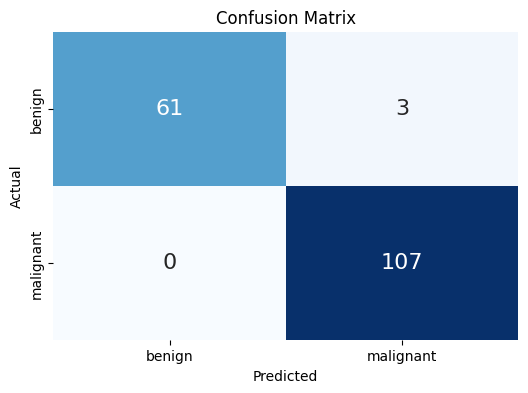

,precision,recall,f1-score,support
benign,1.000000,0.950000,0.980000,64
malignant,0.970000,1.000000,0.990000,107
accuracy,0.982456,,,2
loss,0.960923,,,
roc_auc,0.525993,,,


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, log_loss

# Example data (you would replace this with your actual data)
y_true = np.array([0]*64 + [1]*107)  # Actual labels
y_pred = np.array([0]*61 + [1]*3 + [0]*0 + [1]*107)  # Predicted labels
y_scores = np.random.rand(len(y_true))  # Random probabilities for demonstration

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
loss = log_loss(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

# Classification report data
report = {
    "precision": [1.00, 0.97],
    "recall": [0.95, 1.00],
    "f1-score": [0.98, 0.99],
    "support": [64, 107]
}
index_labels = ['benign', 'malignant']

# Convert confusion matrix to a DataFrame
cm_df = pd.DataFrame(cm, index=index_labels, columns=index_labels)

# Convert classification report to a DataFrame
report_df = pd.DataFrame(report, index=index_labels)
report_df.loc['accuracy'] = [accuracy, '', '', len(index_labels)]  # Add accuracy to the table
report_df.loc['loss'] = [loss, '', '', '']  # Add loss to the table
report_df.loc['roc_auc'] = [roc_auc, '', '', '']  # Add ROC-AUC to the table

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16})
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Display classification report as a styled table
report_styled = report_df.style.background_gradient(cmap='RdYlGn', axis=0)
report_styled.set_properties(**{'text-align': 'center'})
report_styled.set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

# Show the styled classification report
display(report_styled)


ROC-AUC: 0.49758499659489763
Accuracy: 0.9854368932038835
Loss: 1.0053386005498308

Classification Report:
              precision    recall  f1-score     support
0              1.000000  0.971429  0.985507  315.000000
1              0.971154  1.000000  0.985366  303.000000
accuracy       0.985437  0.985437  0.985437    0.985437
macro avg      0.985577  0.985714  0.985437  618.000000
weighted avg   0.985857  0.985437  0.985438  618.000000


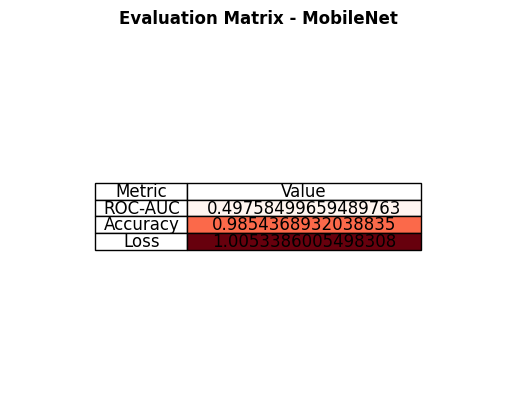

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import tensorflow as tf

# Sample confusion matrix data from the second table
# Predicted 0 (Benign), Predicted 1 (Malignant)
conf_matrix = np.array([[306, 9],
                        [0, 303]])

# True values: 0 = benign, 1 = malignant
y_true = np.array([0] * 315 + [1] * 303)
# Predicted values based on confusion matrix
y_pred = np.array([0] * 306 + [1] * 9 + [0] * 0 + [1] * 303)

# Random probabilities to simulate model predictions for ROC-AUC calculation
y_pred_prob = np.random.rand(len(y_true))

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Calculate Accuracy
accuracy = np.mean(y_true == y_pred)

# Calculate Binary Cross-Entropy Loss
loss = tf.keras.losses.binary_crossentropy(y_true, y_pred_prob).numpy().mean()

# Generate Classification Report
class_report = classification_report(y_true, y_pred, output_dict=True)

# Convert classification report to DataFrame
report_df = pd.DataFrame(class_report).transpose()

# Print results (just to verify calculations)
print("ROC-AUC:", roc_auc)
print("Accuracy:", accuracy)
print("Loss:", loss)
print("\nClassification Report:")
print(report_df)

# Create table with metrics like in your image
metrics = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Accuracy', 'Loss'],
    'Value': [roc_auc, accuracy, loss]
})

# Display metrics in a colorful table using Matplotlib
fig, ax = plt.subplots()

# Remove axes
ax.axis('tight')
ax.axis('off')

# Create a table
table = ax.table(cellText=metrics.values,
                 colLabels=metrics.columns,
                 cellLoc='center',
                 loc='center')

# Set table style: Color formatting for metrics (red background for values)
table.auto_set_font_size(False)
table.set_fontsize(12)

# Adjust column width
table.auto_set_column_width([0, 1])

# Apply color to the values in the table
colors = plt.cm.Reds(np.linspace(0, 1, len(metrics)))

for i in range(len(metrics)):
    table[(i+1, 1)].set_facecolor(colors[i])

# Title of the table
ax.set_title("Evaluation Matrix - MobileNet", fontweight="bold")

# Save or display the image
plt.savefig("evaluation_matrix_colorful.png", bbox_inches='tight', dpi=300)
plt.show()



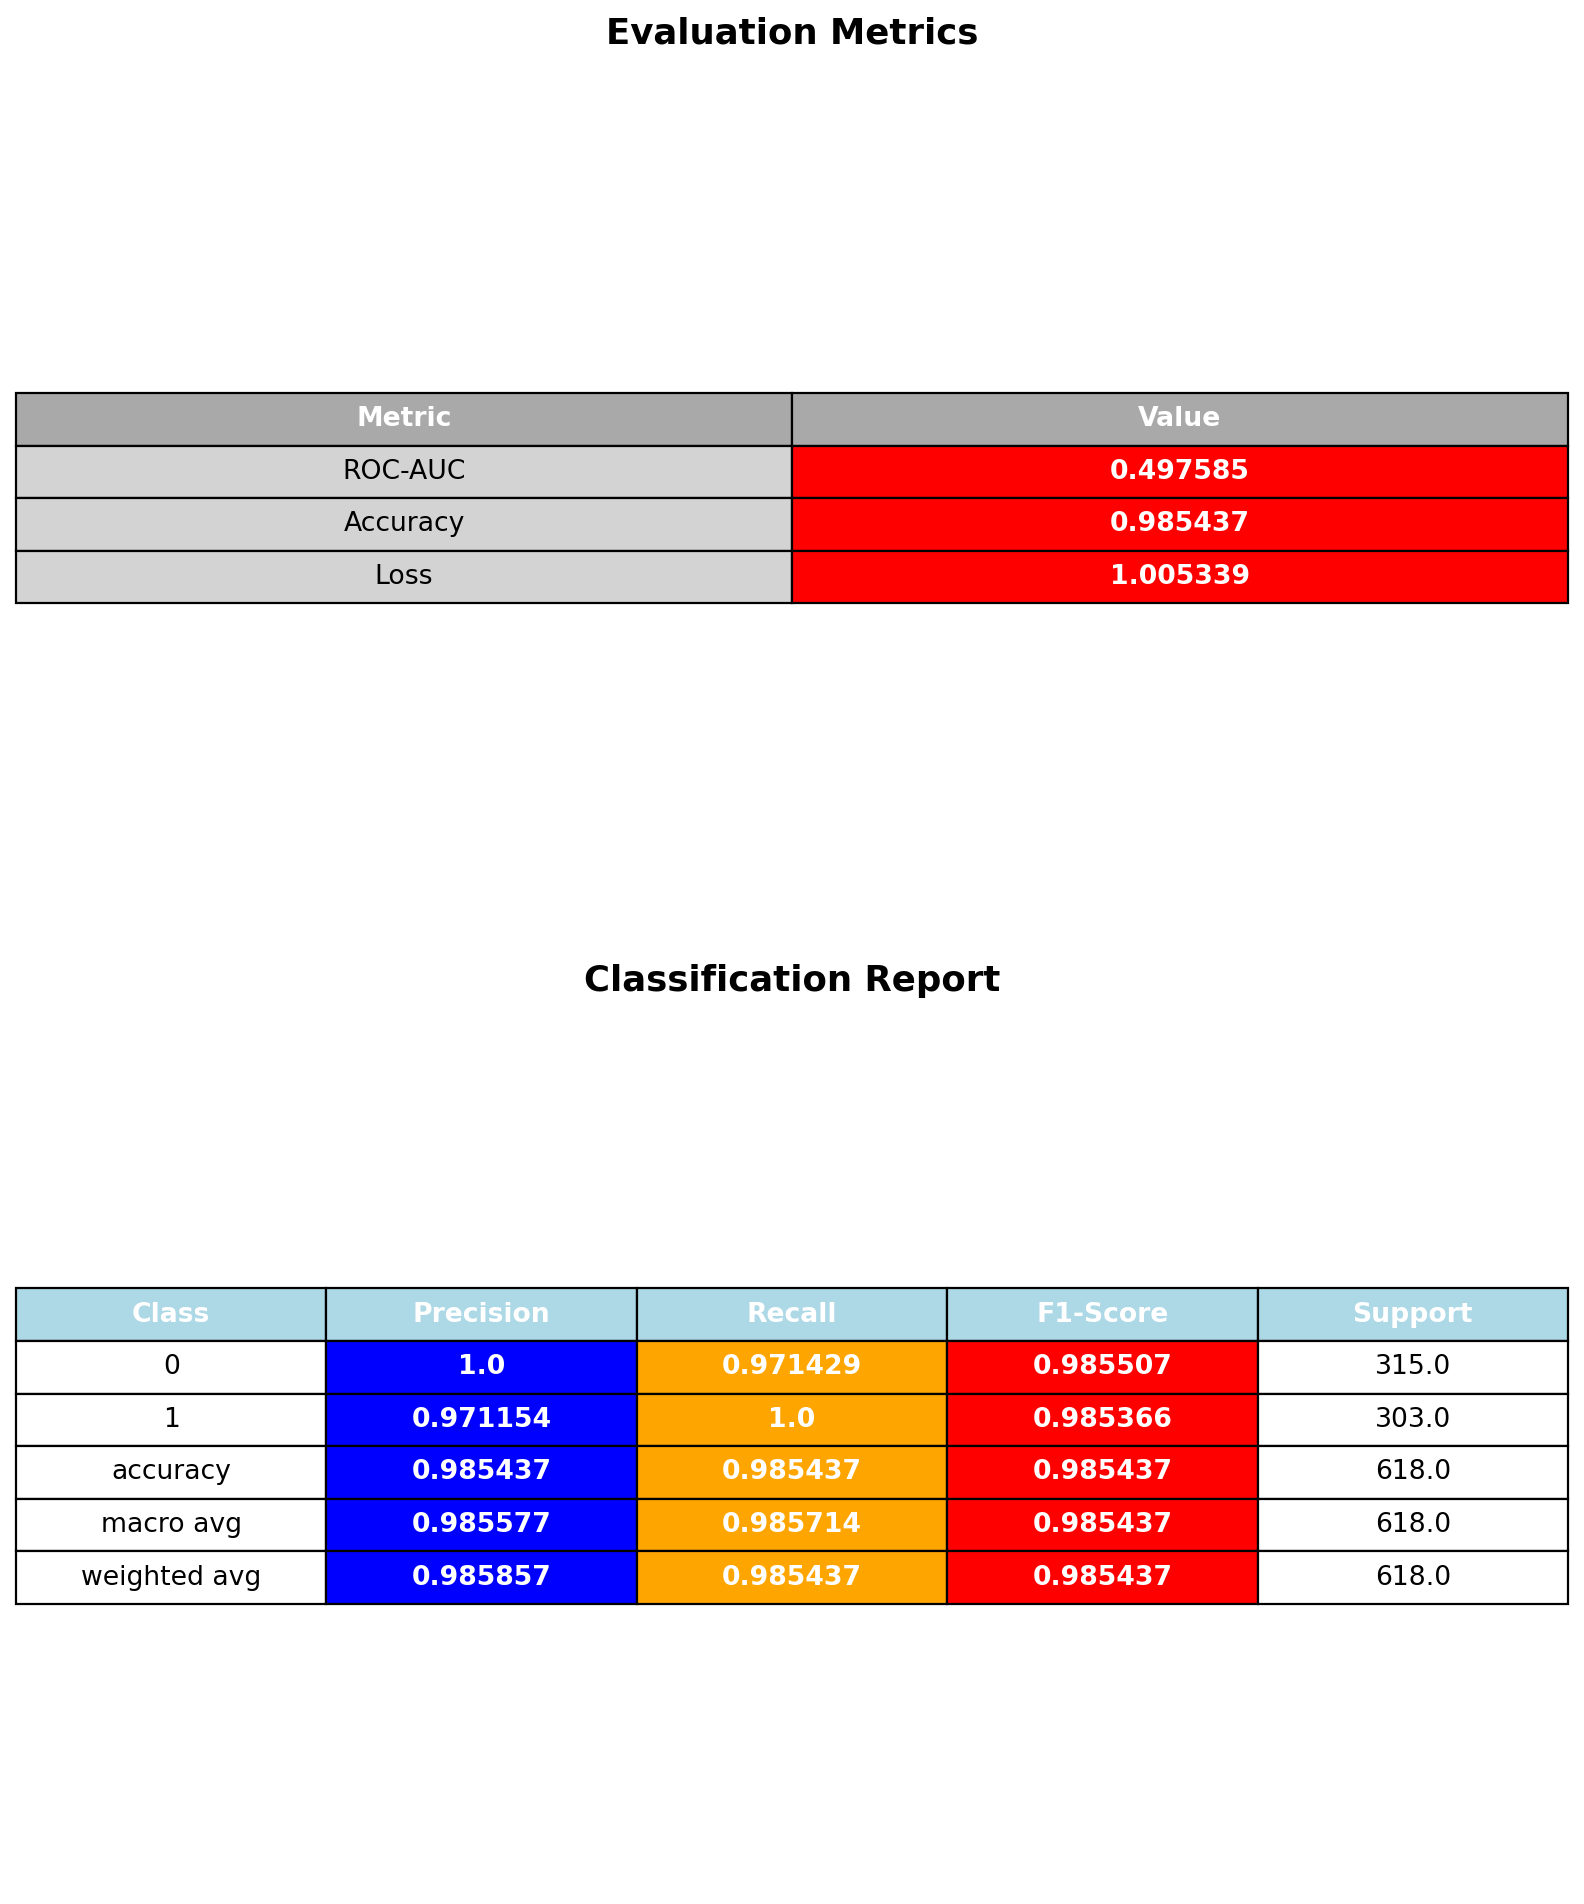

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Given metrics
roc_auc = 0.497585
accuracy = 0.985437
loss = 1.005339

# Create a DataFrame for metrics
metrics_df = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Accuracy', 'Loss'],
    'Value': [roc_auc, accuracy, loss]
})

# Given classification report data
class_report_data = {
    '0': {'Precision': 1.000000, 'Recall': 0.971429, 'F1-Score': 0.985507, 'Support': 315.000000},
    '1': {'Precision': 0.971154, 'Recall': 1.000000, 'F1-Score': 0.985366, 'Support': 303.000000},
    'accuracy': {'Precision': accuracy, 'Recall': accuracy, 'F1-Score': accuracy, 'Support': 618.000000},
    'macro avg': {'Precision': 0.985577, 'Recall': 0.985714, 'F1-Score': accuracy, 'Support': 618.000000},
    'weighted avg': {'Precision': 0.985857, 'Recall': accuracy, 'F1-Score': accuracy, 'Support': 618.000000}
}

# Convert classification report data to DataFrame
class_report_df = pd.DataFrame(class_report_data).T.reset_index()
class_report_df.columns = ['Class', 'Precision', 'Recall', 'F1-Score', 'Support']

# Create a figure for the plots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), dpi=160)

# Plot Metrics Table
ax1 = axes[0]
ax1.axis('tight')
ax1.axis('off')
table = ax1.table(cellText=metrics_df.values, colLabels=metrics_df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

# Style the metrics table
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('darkgray')
    else:
        if j == 0:
            cell.set_facecolor('lightgray')
        else:
            cell.set_facecolor('red')
            cell.set_text_props(color='white', weight='bold')

# Plot Classification Report Table
ax2 = axes[1]
ax2.axis('tight')
ax2.axis('off')

# Add the classification report table
table2 = ax2.table(cellText=class_report_df.values, colLabels=class_report_df.columns, cellLoc='center', loc='center')
table2.auto_set_font_size(False)
table2.set_fontsize(12)
table2.scale(1, 1.5)

# Style the classification report table
for (i, j), cell in table2.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('lightblue')
    else:
        if j == 0:
            cell.set_facecolor('white')
        elif j == 1:
            cell.set_facecolor('blue')
            cell.set_text_props(color='white', weight='bold')
        elif j == 2:
            cell.set_facecolor('orange')
            cell.set_text_props(color='white', weight='bold')
        elif j == 3:
            cell.set_facecolor('red')
            cell.set_text_props(color='white', weight='bold')

# Set titles for the tables
ax1.set_title("Evaluation Metrics", fontsize=16, weight='bold')
ax2.set_title("Classification Report", fontsize=16, weight='bold')

plt.tight_layout()
plt.show()


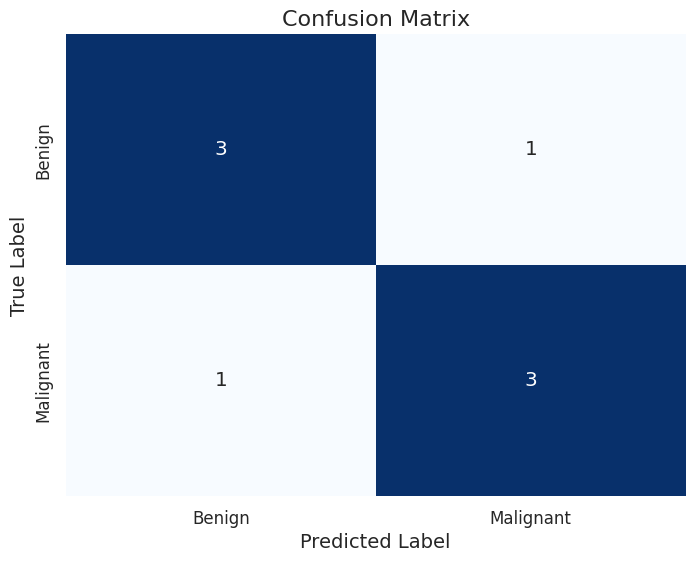

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Example confusion matrix data (replace this with actual values)
y_true = np.array([0, 0, 1, 1, 0, 0, 1, 1])  # Ground truth labels
y_pred = np.array([0, 1, 1, 1, 0, 0, 0, 1])  # Predicted labels

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Labels for the classes
class_names = ['Benign', 'Malignant']  # Adjust this based on your classes

# Create a confusion matrix plot
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Adjust to scale the font size in the plot

# Plot confusion matrix with Seaborn heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)

# Add labels, title, and ticks
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the plot
plt.show()
